#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Data

In [3]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/TCGA_Pan_rna_tf.csv', index_col = 0)
rna

,ENSG00000211592,ENSG00000164930,ENSG00000064961,ENSG00000074219,ENSG00000077150,ENSG00000169136,ENSG00000197905,ENSG00000124226,ENSG00000159184,ENSG00000137166,...,ENSG00000124160,ENSG00000123358,ENSG00000004399,ENSG00000125520,ENSG00000101126,ENSG00000147889,ENSG00000116670,ENSG00000144802,ENSG00000075891,ENSG00000096696
TCGA-D8-A146-01A-31R-A115-07,7654.8063,40.8331,99.4066,71.2573,45.3398,51.0103,16.0300,81.6687,0.0868,52.9615,...,100.0648,46.4742,66.9054,118.9051,101.2596,7.8932,25.0373,55.3425,1.4379,324.6579
TCGA-AQ-A0Y5-01A-11R-A14M-07,10.8013,53.8007,64.8461,27.3517,25.2578,50.7870,26.1682,45.5170,2.3900,77.1110,...,87.2054,20.1423,49.2686,41.1692,107.5493,4.4901,16.6400,5.3116,1.8502,280.7401
TCGA-C8-A274-01A-11R-A16F-07,216.4474,10.6594,67.3339,141.2521,44.0761,27.5640,9.1795,91.8483,15.0755,55.9633,...,100.3860,3.4302,56.1876,109.9864,148.0278,0.8051,20.9096,94.5375,3.7159,218.6022
TCGA-BH-A0BD-01A-11R-A034-07,6638.7969,75.4110,64.3758,83.0089,64.5350,47.0632,26.5756,80.8786,0.0574,49.2848,...,87.3213,7.9767,75.2874,88.0141,79.6633,10.4398,39.9488,5.2551,2.4006,291.8890
TCGA-B6-A1KC-01B-11R-A157-07,74.1970,60.7607,37.1114,3.6246,14.7749,19.7951,10.4981,44.0269,0.0527,55.8907,...,63.6931,3.0929,102.8573,59.7851,94.2117,3.9027,22.1449,4.1008,0.5522,222.3418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-CV-7432-01A-11R-2132-07,200.9838,67.9835,58.9956,20.5237,47.8842,23.6082,73.0152,48.1936,0.0000,27.6437,...,32.1761,6.5242,8.8174,74.9332,38.7384,87.2877,49.9894,2.5136,0.0000,1467.0485
TCGA-IQ-7630-01A-11R-2081-07,139.9574,105.8413,64.0444,38.7878,58.5238,31.5900,40.3814,73.7803,0.0000,29.2523,...,53.0383,7.9319,10.7760,107.2113,55.8860,19.0081,56.1814,19.7964,0.0073,1131.6759
TCGA-H7-A6C4-11A-21R-A466-07,268.1355,8.7504,16.7714,4.9647,20.8897,12.2632,36.1594,16.8386,0.0173,3.4598,...,12.2371,70.7088,4.2489,51.3865,10.8737,0.4861,8.5861,13.6714,0.0082,375.8647
TCGA-H7-8501-01A-11R-2403-07,5129.2628,105.6087,59.0624,9.0926,41.1974,16.3537,138.3765,131.9729,0.0000,15.1099,...,38.9051,17.1940,15.9184,135.3172,41.2385,9.8151,80.5381,34.6077,0.0155,238.6101


In [4]:
drop_cols = []
for i in rna.columns:
  if i.endswith('.1'):
    drop_cols.append(i)
    print(i)

In [5]:
rna = rna.drop(columns = drop_cols)
for i in rna.columns:
  if i.endswith('.1'):
    print(i)

In [6]:
rna.head(3)

,ENSG00000211592,ENSG00000164930,ENSG00000064961,ENSG00000074219,ENSG00000077150,ENSG00000169136,ENSG00000197905,ENSG00000124226,ENSG00000159184,ENSG00000137166,...,ENSG00000124160,ENSG00000123358,ENSG00000004399,ENSG00000125520,ENSG00000101126,ENSG00000147889,ENSG00000116670,ENSG00000144802,ENSG00000075891,ENSG00000096696
TCGA-D8-A146-01A-31R-A115-07,7654.8063,40.8331,99.4066,71.2573,45.3398,51.0103,16.0300,81.6687,0.0868,52.9615,...,100.0648,46.4742,66.9054,118.9051,101.2596,7.8932,25.0373,55.3425,1.4379,324.6579
TCGA-AQ-A0Y5-01A-11R-A14M-07,10.8013,53.8007,64.8461,27.3517,25.2578,50.7870,26.1682,45.5170,2.3900,77.1110,...,87.2054,20.1423,49.2686,41.1692,107.5493,4.4901,16.6400,5.3116,1.8502,280.7401
TCGA-C8-A274-01A-11R-A16F-07,216.4474,10.6594,67.3339,141.2521,44.0761,27.5640,9.1795,91.8483,15.0755,55.9633,...,100.3860,3.4302,56.1876,109.9864,148.0278,0.8051,20.9096,94.5375,3.7159,218.6022


#Log2 transformation

In [7]:
rna = rna.apply(lambda x: np.log2(x + 1))
rna.head(3)

,ENSG00000211592,ENSG00000164930,ENSG00000064961,ENSG00000074219,ENSG00000077150,ENSG00000169136,ENSG00000197905,ENSG00000124226,ENSG00000159184,ENSG00000137166,...,ENSG00000124160,ENSG00000123358,ENSG00000004399,ENSG00000125520,ENSG00000101126,ENSG00000147889,ENSG00000116670,ENSG00000144802,ENSG00000075891,ENSG00000096696
TCGA-D8-A146-01A-31R-A115-07,12.902339,5.386573,6.649710,6.175071,5.534180,5.700725,4.090007,6.369269,0.120086,5.753859,...,6.659137,5.569072,6.085454,6.905749,6.676092,3.152703,4.702508,5.816152,1.285639,8.347213
TCGA-AQ-A0Y5-01A-11R-A14M-07,3.560874,5.776122,6.041026,4.825363,4.714674,5.694518,4.763847,5.539686,1.761285,6.287454,...,6.462795,4.402060,5.651586,5.398118,6.762207,2.456832,4.140779,2.658006,1.511063,8.138221
TCGA-C8-A274-01A-11R-A16F-07,7.764523,3.543422,6.094530,7.152306,5.494291,4.836126,3.347595,6.536804,4.006792,5.831961,...,6.663715,2.147372,5.837630,6.794239,7.219438,0.852079,4.453491,6.577995,2.237533,7.778749


#Data shuffling

In [8]:
shuffled_data = rna.sample(frac=1, random_state=0)
shuffled_rna = shuffled_data[rna.columns]
rna = shuffled_rna
rna.head(3)

,ENSG00000211592,ENSG00000164930,ENSG00000064961,ENSG00000074219,ENSG00000077150,ENSG00000169136,ENSG00000197905,ENSG00000124226,ENSG00000159184,ENSG00000137166,...,ENSG00000124160,ENSG00000123358,ENSG00000004399,ENSG00000125520,ENSG00000101126,ENSG00000147889,ENSG00000116670,ENSG00000144802,ENSG00000075891,ENSG00000096696
TCGA-D1-A17S-01A-11R-A12I-07,7.589774,3.345709,6.588452,5.470094,5.224827,4.367539,2.700839,4.534666,0.000000,4.694022,...,5.018665,1.600508,3.150267,5.405084,4.769666,1.878333,3.462314,2.325703,0.042924,3.692617
TCGA-24-1564-01A-01R-1566-13,9.752921,6.498479,6.126649,5.834956,6.853336,5.593551,5.452846,6.677873,0.226509,8.207853,...,6.471173,3.808282,6.829869,6.809239,7.455220,2.693253,5.128182,3.812919,7.480591,8.047889
TCGA-BR-6456-01A-11R-1802-13,13.203806,5.382297,6.195292,4.966546,7.123875,4.906347,5.589065,6.993592,2.742308,6.404176,...,6.427863,7.119558,6.405061,6.759595,5.921327,6.213791,4.788122,5.633141,0.022900,6.891052


#Data imputation and normalization [-1, 1]

In [9]:
from sklearn.impute import SimpleImputer

def impute_normalize(df):
  data = df.copy()
  imputer = SimpleImputer(strategy='median')
  data = imputer.fit_transform(data)
  min_val = np.min(data)
  max_val = np.max(data)
  data_scaled = 2 * ((data - min_val) / (max_val - min_val)) - 1
  data_scaled = data_scaled.astype(np.float32)
  print('min:', np.min(data_scaled))
  print('max:', np.max(data_scaled))
  print('shape:', data_scaled.shape)

  return data_scaled

#Neural network

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [11]:
X = rna.drop(labels = ['ENSG00000211592'], axis = 'columns')
y = rna[['ENSG00000211592']]

In [12]:
input_features = X.columns.tolist()
input_features

['ENSG00000164930',
 'ENSG00000064961',
 'ENSG00000074219',
 'ENSG00000077150',
 'ENSG00000169136',
 'ENSG00000197905',
 'ENSG00000124226',
 'ENSG00000159184',
 'ENSG00000137166',
 'ENSG00000108654',
 'ENSG00000168496',
 'ENSG00000055130',
 'ENSG00000163132',
 'ENSG00000124575',
 'ENSG00000165672',
 'ENSG00000107447',
 'ENSG00000126778',
 'ENSG00000113068',
 'ENSG00000112715',
 'ENSG00000163558',
 'ENSG00000215301',
 'ENSG00000087191',
 'ENSG00000135111',
 'ENSG00000111206',
 'ENSG00000168283',
 'ENSG00000117318',
 'ENSG00000213676',
 'ENSG00000172534',
 'ENSG00000144485',
 'ENSG00000114554',
 'ENSG00000115641',
 'ENSG00000165030',
 'ENSG00000106261',
 'ENSG00000196843',
 'ENSG00000196975',
 'ENSG00000106483',
 'ENSG00000136997',
 'ENSG00000135363',
 'ENSG00000103994',
 'ENSG00000173253',
 'ENSG00000180818',
 'ENSG00000197780',
 'ENSG00000204209',
 'ENSG00000157933',
 'ENSG00000118418',
 'ENSG00000185650',
 'ENSG00000164920',
 'ENSG00000170608',
 'ENSG00000082175',
 'ENSG00000137310',


In [13]:
import pickle

with open('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/ENSG00000211592_tfs_nn_model_input_features.pkl', 'wb') as f:
  pickle.dump(input_features, f)

In [14]:
X = X.values
y = y.values

In [15]:
print(X.shape)
print(y.shape)

(10668, 682)
(10668, 1)


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.1, random_state = 0)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 0)

X_train = impute_normalize(X_train)
X_test = impute_normalize(X_test)
X_val = impute_normalize(X_val)
y_train = impute_normalize(y_train)
y_test = impute_normalize(y_test)
y_val = impute_normalize(y_val)

print('Train data:')
print(X_train.shape)
print(y_train.shape)

print('Test data:')
print(X_test.shape)
print(y_test.shape)

print('Val data:')
print(X_val.shape)
print(y_val.shape)

min: -1.0
max: 1.0
shape: (9601, 682)
min: -1.0
max: 1.0
shape: (533, 682)
min: -1.0
max: 1.0
shape: (534, 682)
min: -1.0
max: 1.0
shape: (9601, 1)
min: -1.0
max: 1.0
shape: (533, 1)
min: -1.0
max: 1.0
shape: (534, 1)
Train data:
(9601, 682)
(9601, 1)
Test data:
(533, 682)
(533, 1)
Val data:
(534, 682)
(534, 1)


In [17]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout


model = keras.Sequential([
    layers.Input(shape = (X_train.shape[1],)),
    layers.Dense(1024, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),

    layers.Dense(512, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),

    layers.Dense(256, activation = 'relu'),
    BatchNormalization(),
    Dropout(0.5),

    keras.layers.Dense(1, activation='linear')
])

In [18]:
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │       699,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,362,945 (5.20 MB)

 Trainable params: 1,359,361 (5.19 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [19]:
history = model.fit(X_train, y_train,
                    epochs=1000,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    shuffle = True,
                    callbacks=[tf.keras.callbacks.EarlyStopping(patience=100, restore_best_weights=True)]
                    )

Epoch 1/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 2.1106 - mae: 1.0979 - val_loss: 0.1458 - val_mae: 0.3020
Epoch 2/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2925 - mae: 0.4106 - val_loss: 0.0555 - val_mae: 0.1879
Epoch 3/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0939 - mae: 0.2391 - val_loss: 0.0444 - val_mae: 0.1667
Epoch 4/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0635 - mae: 0.1991 - val_loss: 0.0348 - val_mae: 0.1495
Epoch 5/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0528 - mae: 0.1814 - val_loss: 0.0285 - val_mae: 0.1345
Epoch 6/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0469 - mae: 0.1701 - val_loss: 0.0304 - val_mae: 0.1383
Epoch 7/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0442 - mae: 0.1639 - val_loss: 0.0266 - val_mae: 0.1280
Epoch 8/1000
301/301 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0412 - mae: 0.1595 - val_loss: 0.0301 - val_mae: 0.1367
Epoch 9/1000
301/301 ━━━━━━━━━━━━━━━━━━

In [20]:
model.save('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/models/ENSG00000211592_tfs_nn_model.keras')

In [21]:
loss, mae = model.evaluate(X_test, y_test, verbose=1)
print("Mean Absolute Error:", mae)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0240 - mae: 0.1216
Mean Absolute Error: 0.1228332668542862


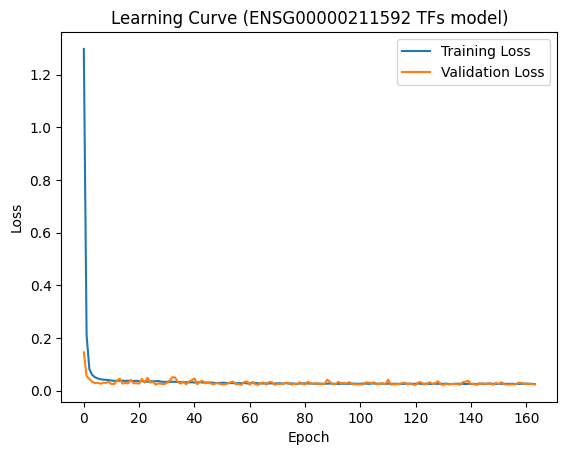

In [22]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve (ENSG00000211592 TFs model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/ENSG00000211592_tfs_learning_curve.svg', bbox_inches = 'tight')
plt.show()

In [23]:
train_loss = history.history['loss'][-1]
train_mae = history.history['mae'][-1]
print(f"Training Loss: {train_loss:.4f}")
print(f"Training MAE: {train_mae:.4f}")

Training Loss: 0.0255
Training MAE: 0.1250


In [24]:
val_loss = history.history['val_loss'][-1]
val_mae = history.history['val_mae'][-1]
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation MAE: {val_mae:.4f}")

Validation Loss: 0.0232
Validation MAE: 0.1182


In [25]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

Test Loss: 0.0258
Test MAE: 0.1228


In [26]:
predictions = model.predict(X_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


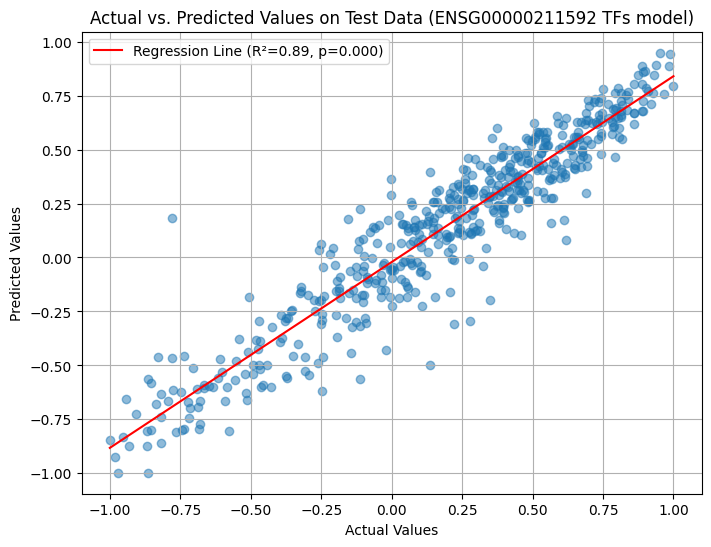

R-squared: 0.8909
P-value: 0.0000


In [27]:
from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np

# Calculate the regression line and statistics
slope, intercept, r_value, p_value, std_err = linregress(y_test.flatten(), predictions.flatten())

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.5)

x_values = np.array([y_test.min(), y_test.max()])
plt.plot(x_values, intercept + slope * x_values, color='red', label=f'Regression Line (R²={r_value**2:.2f}, p={p_value:.3f})')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values on Test Data (ENSG00000211592 TFs model)")
plt.grid(True)
plt.legend()
plt.savefig('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/plots/ENSG00000211592_TFs_Reg_plot_actual_pred_.svg', bbox_inches = 'tight')
plt.show()

print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")